<a href="https://colab.research.google.com/github/hvmdvvn/Intro-to-Computer-Vision/blob/main/Lab_11_Blob_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Gemini_Generated_Image_4idpj44idpj44idp.png to Gemini_Generated_Image_4idpj44idpj44idp.png


In [12]:
leaves = cv2.imread('/content/Gemini_Generated_Image_4idpj44idpj44idp.png')
leaves = cv2.cvtColor(leaves, cv2.COLOR_BGR2RGB)

# If you have a pre-made binary mask, load it
# Otherwise, we will generate one automatically
try:
    mask = cv2.imread('leaves_mask.jpg', 0)
except:
    mask = None


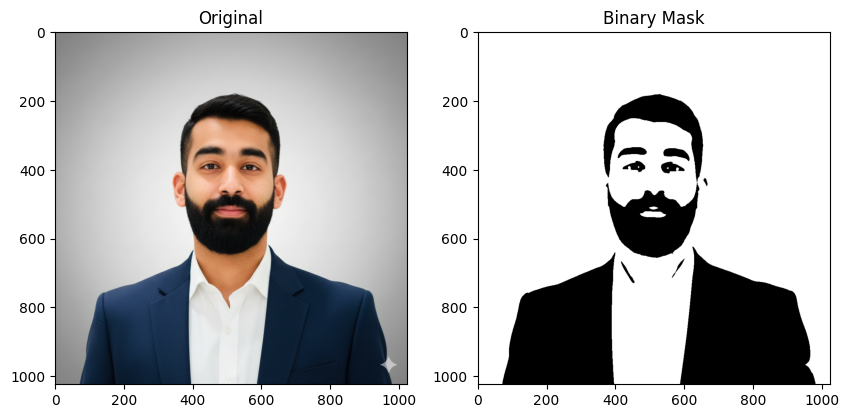

In [13]:
if mask is None:
    gray = cv2.cvtColor(leaves, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (11,11), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(leaves); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(mask, cmap='gray'); plt.title("Binary Mask")
plt.show()

In [14]:
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 200
params.maxArea = 50000

params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(mask)

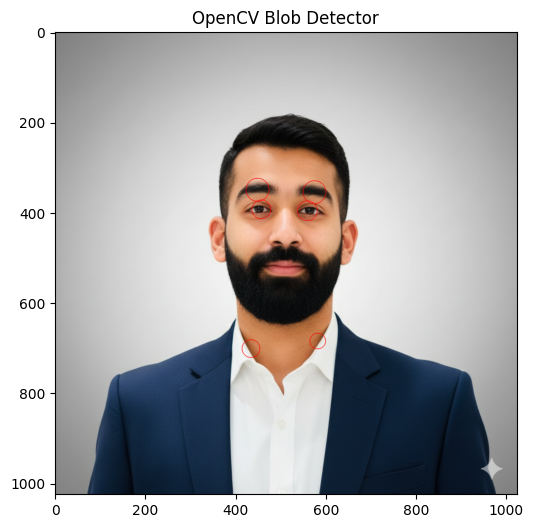

In [15]:
detected = cv2.drawKeypoints(leaves, keypoints, np.array([]),
                             (255,0,0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(6,6))
plt.imshow(detected)
plt.title("OpenCV Blob Detector")
plt.show()

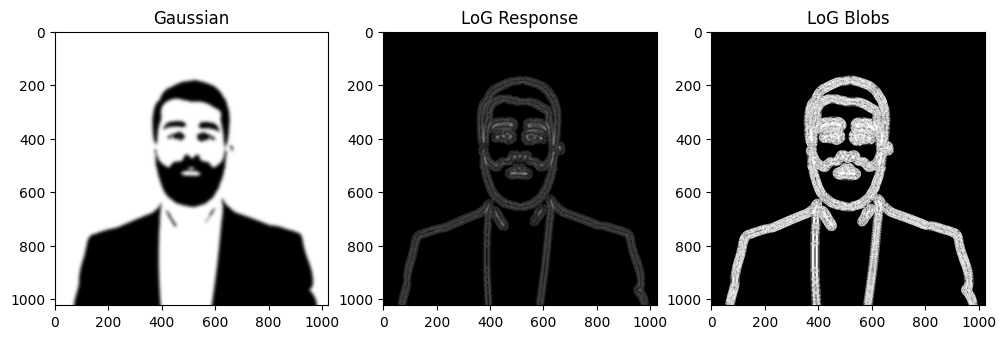

In [16]:
# Apply Gaussian blur
gauss = cv2.GaussianBlur(mask, (0,0), sigmaX=6)

# Laplacian
lap = cv2.Laplacian(gauss, cv2.CV_64F)
lap = np.absolute(lap)
lap_norm = cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")

# Threshold for blobs
_, th = cv2.threshold(lap_norm, 30, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gauss, cmap='gray'); plt.title("Gaussian")
plt.subplot(1,3,2); plt.imshow(lap_norm, cmap='gray'); plt.title("LoG Response")
plt.subplot(1,3,3); plt.imshow(th, cmap='gray'); plt.title("LoG Blobs")
plt.show()

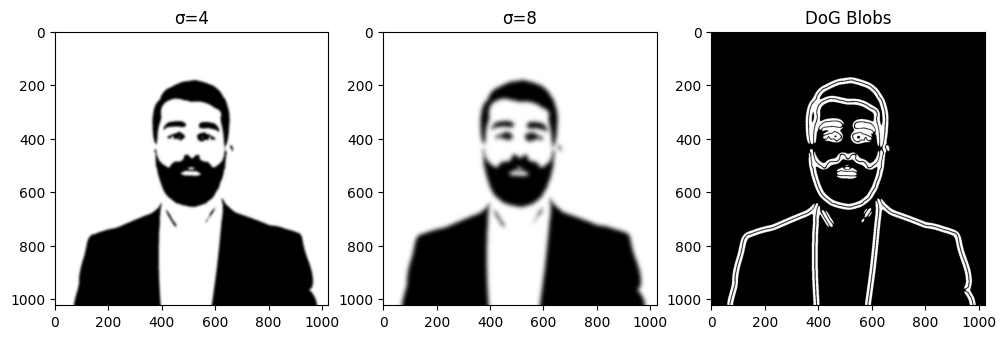

In [17]:
g1 = cv2.GaussianBlur(mask, (0,0), sigmaX=4)
g2 = cv2.GaussianBlur(mask, (0,0), sigmaX=8)

dog = cv2.absdiff(g1, g2)
_, th_dog = cv2.threshold(dog, 20, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(g1, cmap='gray'); plt.title("σ=4")
plt.subplot(1,3,2); plt.imshow(g2, cmap='gray'); plt.title("σ=8")
plt.subplot(1,3,3); plt.imshow(th_dog, cmap='gray'); plt.title("DoG Blobs")
plt.show()

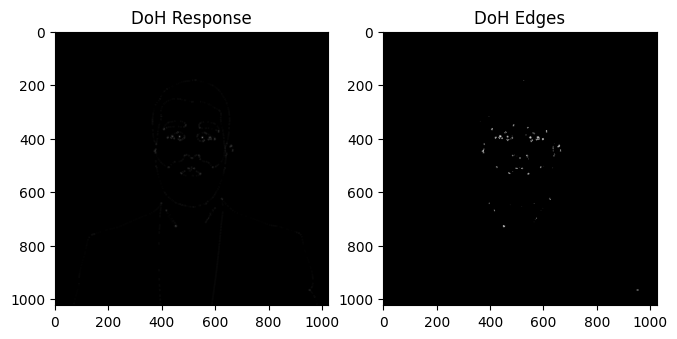

In [18]:
gray = cv2.GaussianBlur(mask, (7,7), 0)

# Hessian components
Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
Ixx = cv2.Sobel(Ix,  cv2.CV_64F, 1, 0, ksize=5)
Iyy = cv2.Sobel(Iy,  cv2.CV_64F, 0, 1, ksize=5)
Ixy = cv2.Sobel(Ix,  cv2.CV_64F, 0, 1, ksize=5)

# Determinant of Hessian
DoH = (Ixx * Iyy) - (Ixy**2)
abs_DoH = np.abs(DoH)
abs_DoH = cv2.normalize(abs_DoH, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

_, th_doh = cv2.threshold(abs_DoH, 30, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(abs_DoH, cmap='gray'); plt.title("DoH Response")
plt.subplot(1,3,2); plt.imshow(th_doh, cmap='gray'); plt.title("DoH Edges")
plt.show()